In [1]:
%load_ext autoreload
%autoreload 2
import jax
import jax.numpy as jnp

from sklearn.datasets import make_s_curve, make_blobs
import sklearn

import matplotlib.pyplot as plt
import plotly.express as px

from jax.example_libraries import stax

import numpyro
import numpyro.distributions as dist
from numpyro.infer import SVI, Trace_ELBO
from numpyro import optim
from numpyro.infer import Predictive
from numpyro import handlers



from numpyro.contrib.einstein import RBFKernel
from CustomModules.mixture_guide_impl_source import MixtureGuidePredictive
from CustomModules.stein_impl_source import SteinVI
from CustomModules.single_site_rbf import SingleSiteRBFKernel
from CustomModules.architectures import *



from morbius import make_mobius_strip
from checker import make_nd_checkerboard
rng_key = jax.random.key(42)

from CustomModules.normalizing_flow import normalizing_flow

In [2]:
def plot3d(d, title):
    d = d.reshape(-1, 3)
    fig = px.scatter_3d(x=d[:,0], y=d[:,1], z=d[:,2], title=title)
    fig.update_traces(marker=dict(size=2))


    fig.update_layout(
        title_text=title,
        title_x=0.5,              
        title_y=0.95,               
        title_font_family="Arial",  
        title_font_size=24,        
        title_font_color="navy",     
        margin=dict(t=60)            
    )

    fig.show()


In [3]:

X_3d_checkerboard = make_nd_checkerboard(2000, grid_shape=(4, 4, 1))[0]

plot3d(X_3d_checkerboard, "Checkerboard")

In [4]:
import numpy as np

n_samples = 2000

X_mobius, _  = make_mobius_strip(n_samples=2000, radius = 2, width = 3, noise=0.2)

plot3d(X_mobius, "Möbius Strip")

In [5]:
X_S, t = make_s_curve(noise=0.10, random_state=0, n_samples=1000)
plot3d(X_S, "Curve Data")

In [38]:
X_blobs, _=  make_blobs(centers=2,n_features=3, cluster_std=0.5, random_state=0, n_samples=1000)
plot3d(X_blobs, "Blob Data")

# Basic VAE

In [39]:

def encoder(hidden_dim, z_dim):
    return stax.serial(
        stax.Dense(hidden_dim, W_init=stax.randn()),
        stax.Softplus,
        stax.Dense(hidden_dim, W_init=stax.randn()),
        stax.Softplus,
        stax.FanOut(2),
        stax.parallel(
            stax.Dense(z_dim, W_init=stax.randn()),
            stax.serial(stax.Dense(z_dim, W_init=stax.randn()), stax.Exp),
        ),
    )




def decoder(hidden_dim, out_dim):
    return stax.serial(
        stax.Dense(hidden_dim, W_init=stax.randn()),
        stax.Softplus,
        stax.Dense(hidden_dim, W_init=stax.randn()),
        stax.Softplus,
        stax.Dense(out_dim, W_init=stax.randn()),
    )



def mean_network(hidden_dim, m_dim):
    SafeSoftplus = stax.elementwise(lambda x: jnp.log(1 + jnp.exp(x - 3.0)) + 1e-5)
    return stax.serial(
        stax.Dense(hidden_dim, W_init=stax.randn()),
        stax.Softplus,
        stax.Dense(hidden_dim, W_init=stax.randn()),
        stax.Softplus,
        stax.FanOut(2),
        stax.parallel(
            stax.Dense(m_dim, W_init=stax.randn()),
            stax.serial(stax.Dense(m_dim, W_init=stax.randn()), SafeSoftplus),
        ),
    )



In [ ]:
X = X_3d_checkerboard

batch_size = X.shape[0]
dataloader = [X[i:i+batch_size] for i in range(0, len(X), batch_size)]

out_dim = X.reshape(X.shape[0], -1).shape[1]

hidden_dim = 8
z_dim = 2
lr=5e-3
adam = optim.Adam(lr)


encoder_args = {"hidden_dim": hidden_dim, "z_dim": z_dim}
decoder_args = {"hidden_dim": hidden_dim, "out_dim": out_dim}
mean_network_args = {"hidden_dim": hidden_dim, "m_dim": z_dim}

In [41]:
def plot_vae(vae, rng_key, share_axis=True):
    rng_key, e_sub, d_sub, s_sub = jax.random.split(rng_key, 4)

    values = vae.encode_batch(X, e_sub)
    X_recon = vae.decode_latent({"z": values["z"]}, d_sub)

    has_m = values.get("m") is not None
    c_recon = values.get("pidx")

    plot3d(X_recon["obs"], "recon")

    fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=share_axis, sharey=share_axis)

    for ax in axes.flat:
        ax.set_aspect('equal')

    axes[0, 0].scatter(values["z"][:, 0], values["z"][:, 1], c=c_recon)
    axes[0, 0].set_title("recon latent (z)")

    if has_m:
        axes[0, 1].scatter(values["m"][:, 0], values["m"][:, 1], c=c_recon)
        axes[0, 1].set_title("recon latent (m)")
    else:
        axes[0, 1].axis("off")

    values = vae.sample(s_sub, 1000)
    plot3d(values["obs"], "samples")

    c_samp = values.get("pidx")

    axes[1, 0].scatter(values["z"][:, 0], values["z"][:, 1], c=c_samp)
    axes[1, 0].set_title("samples latent (z)")

    if has_m:
        axes[1, 1].scatter(values["m"][:, 0], values["m"][:, 1], c=c_samp)
        axes[1, 1].set_title("samples latent (m)")
    else:
        axes[1, 1].axis("off")

    plt.tight_layout()
    plt.show()

# Just a model flow

In [29]:
rng_key, sub_key = jax.random.split(rng_key)
flow_args = {"input_dim": z_dim, "hidden_dims": [2, 2], "steps": 10, "inv": True}
base_vae = FlowBasicVAE(encoder, encoder_args, decoder, decoder_args, z_dim, normalizing_flow, flow_args)

base_vae.train(dataloader, X.shape[0], adam, 10000, sub_key)




  0%|          | 0/10000 [00:00<?, ?it/s]/home/kenn50/miniconda3/envs/wsl-test/lib/python3.12/site-packages/jax/_src/api_util.py:293: UserWarning:

Found vars in model but not guide: {'m'}

100%|██████████| 10000/10000 [00:57<00:00, 172.56it/s]


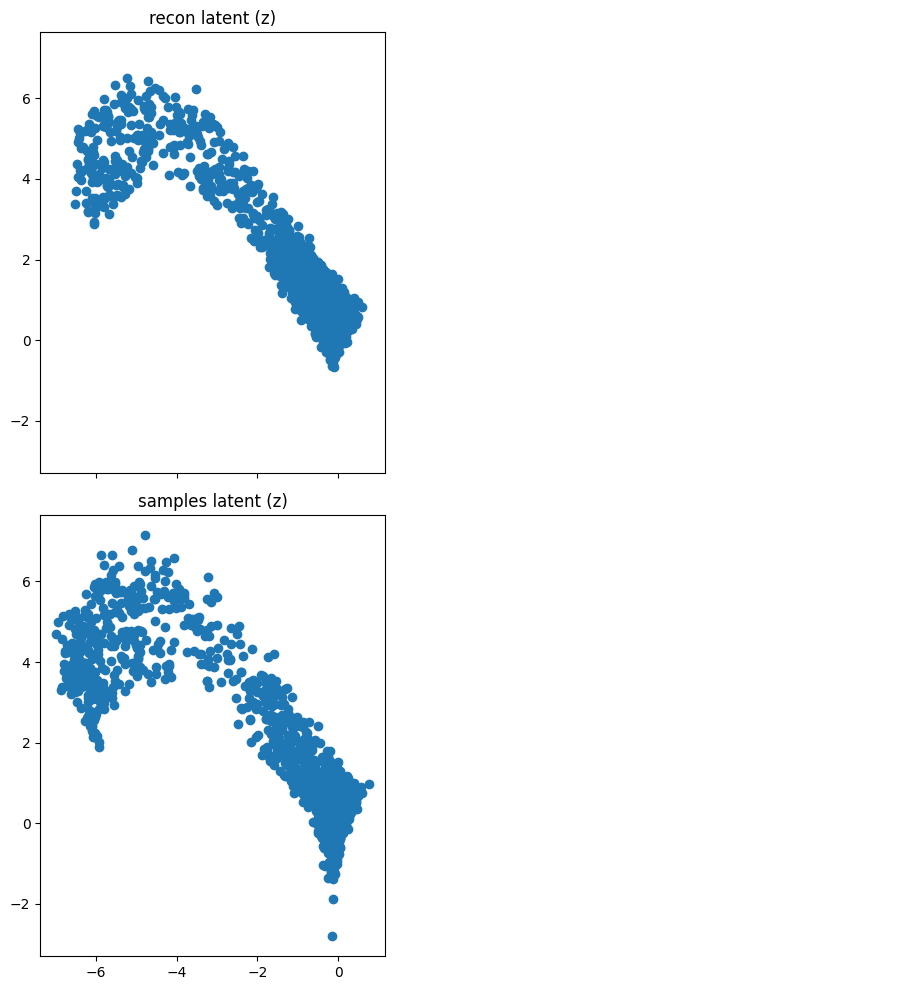

In [30]:
plot_vae(base_vae, sub_key)

# A global Parameter


In [155]:
rng_key, sub_key = jax.random.split(rng_key)

global_vae = GlobalVAE(encoder, encoder_args, decoder, decoder_args, z_dim)

global_vae.train(dataloader, X.shape[0], adam, 10000, sub_key)




100%|██████████| 10000/10000 [00:16<00:00, 619.86it/s]


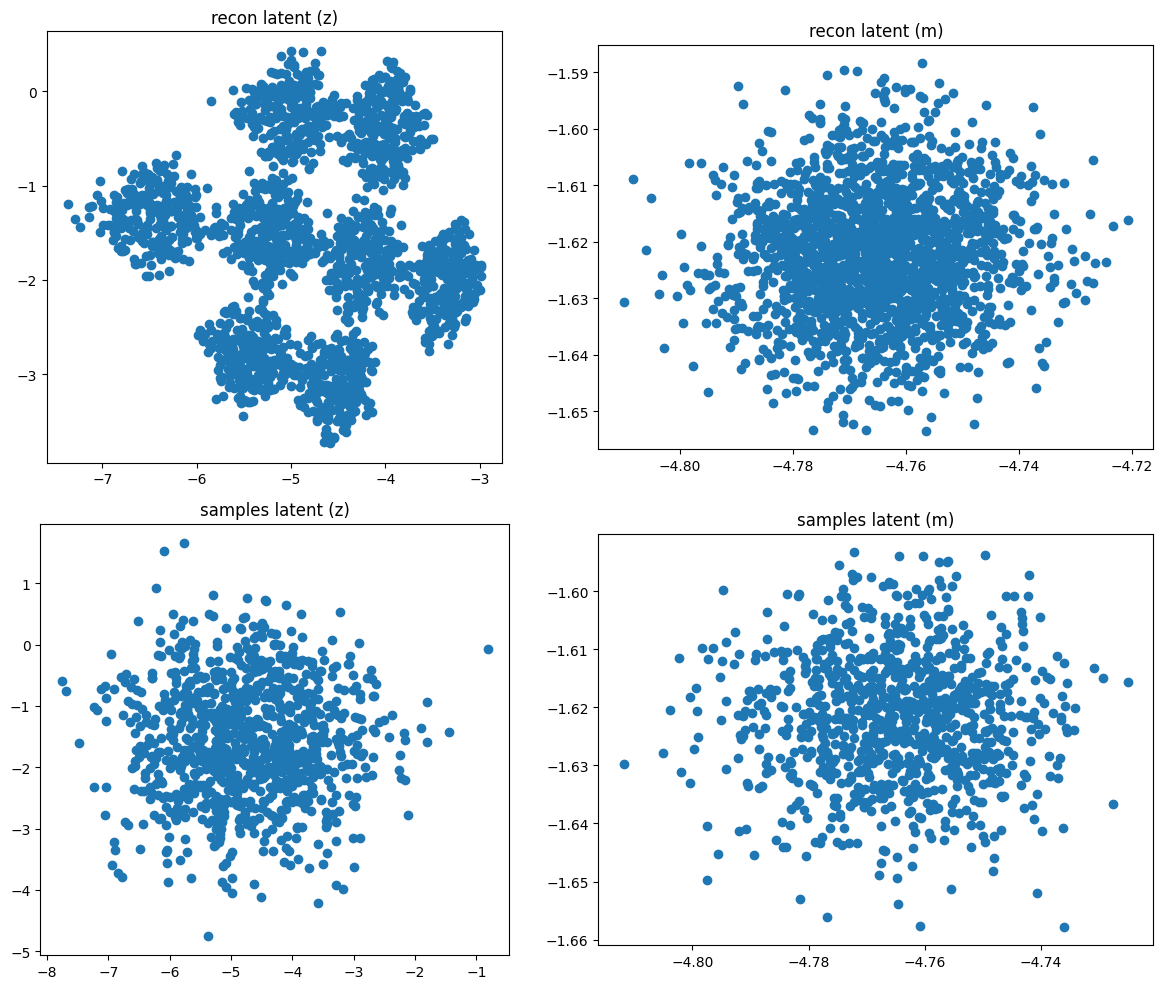

In [156]:
plot_vae(global_vae, sub_key, False)

# Stein global

In [157]:
rng_key, sub_key = jax.random.split(rng_key)

stein_global_vae = SteinGlobalVAE(encoder, encoder_args, decoder, decoder_args, z_dim)

stein_global_vae.train(dataloader, X.shape[0], adam, 10000, sub_key, 5, repulsion_temperature=1)




Epoch 9975, Loss: 282.80: 100%|██████████| 10000/10000 [00:43<00:00, 230.04it/s]


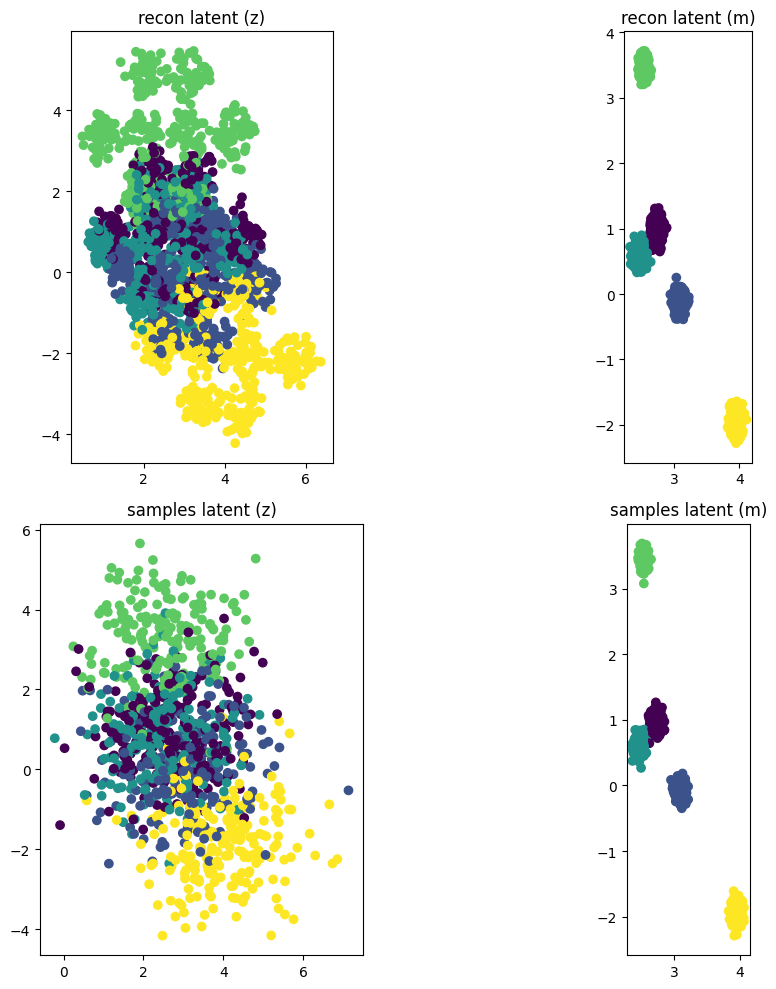

In [158]:
plot_vae(stein_global_vae, sub_key, False)

# Guide Flow


In [167]:
rng_key, sub_key = jax.random.split(rng_key)


flow_args = {"input_dim": z_dim, "hidden_dims": [2, 2], "steps": 10, "inv": True}

guide_flow_vae = GuideFlowGlobalVAE(encoder, encoder_args, decoder, decoder_args, z_dim, flow=normalizing_flow, flow_args=flow_args)

guide_flow_vae.train(dataloader, X.shape[0], adam, 10000, sub_key)



100%|██████████| 10000/10000 [00:25<00:00, 391.86it/s]


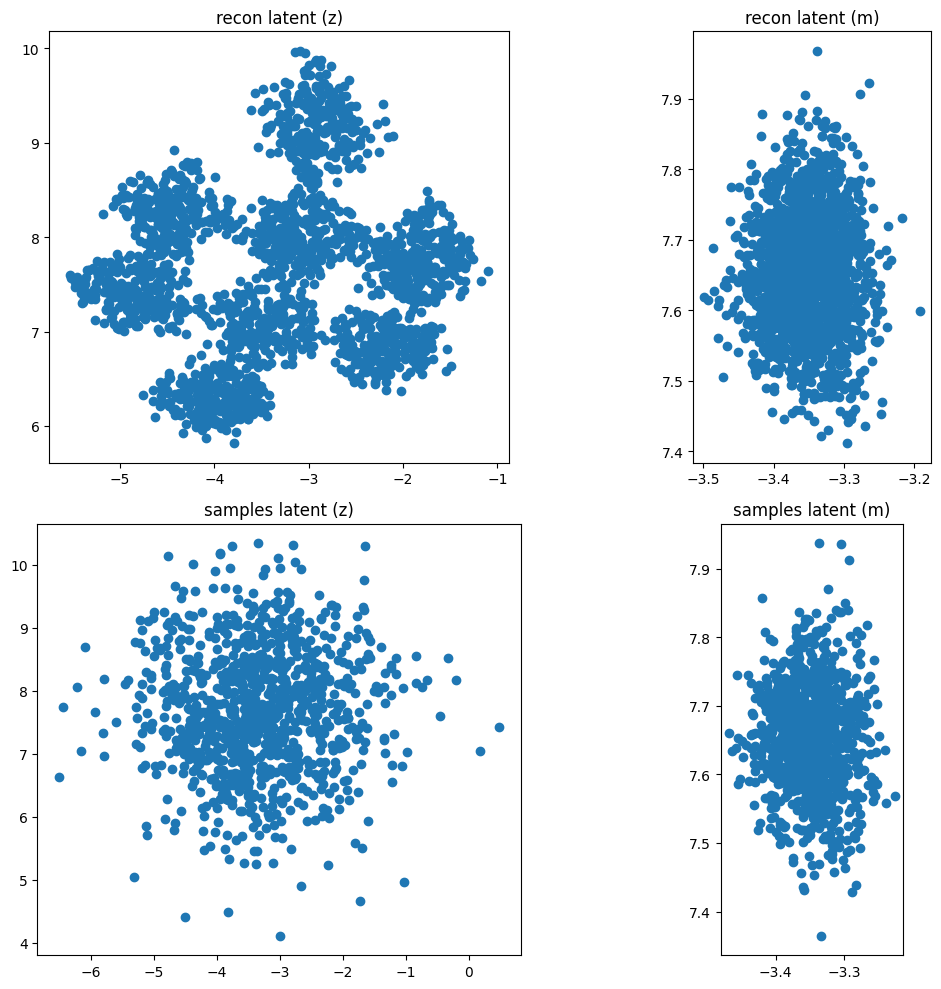

In [170]:
plot_vae(guide_flow_vae, sub_key, False)

# STEIN GUIDE FLOW

In [42]:
rng_key, sub_key = jax.random.split(rng_key)
clipped_adam = optim.ClippedAdam(lr, 10)

flow_args = {"input_dim": z_dim, "hidden_dims": [2, 2], "steps": 5, "inv": True}

stein_guide_flow_vae = SteinGuideFlowVAE(encoder, encoder_args, decoder, decoder_args, z_dim, flow=normalizing_flow, flow_args=flow_args)

stein_guide_flow_vae.train(dataloader, X.shape[0], adam, 5000, sub_key, num_stein_particles=3, repulsion_temperature=1)



  0%|          | 0/5000 [00:31<?, ?it/s]


KeyboardInterrupt: 

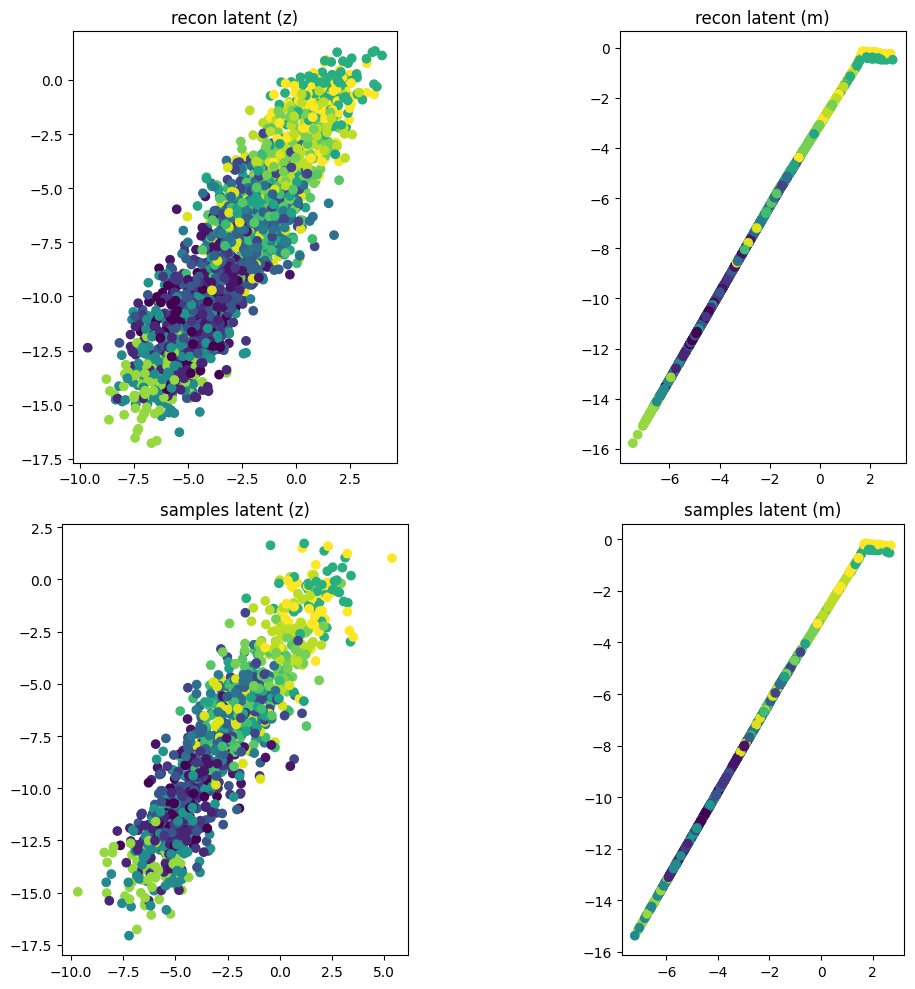

In [ ]:
rng_key, sub_key = jax.random.split(rng_key)
plot_vae(stein_guide_flow_vae, sub_key, False)

# Learned Mean Stein

In [ ]:
rng_key, sub_key = jax.random.split(rng_key)

flow_args = {"input_dim": z_dim, "hidden_dims": [2, 2], "steps": 5, "inv": True}

learned_mean_stein_guide_flow_vae = LearnedMeanSteinGuideFlowVAE(encoder, encoder_args, decoder, 
                                                    decoder_args, mean_network, mean_network_args, 
                                                    z_dim, flow=normalizing_flow, flow_args=flow_args)

learned_mean_stein_guide_flow_vae.train(dataloader, X.shape[0], optim.Adam(0.003), 6000, sub_key, num_stein_particles=3, repulsion_temperature=1, bandwidth_scaler=50)



Epoch 5975, Loss: 1265.54: 100%|██████████| 6000/6000 [00:50<00:00, 119.58it/s]


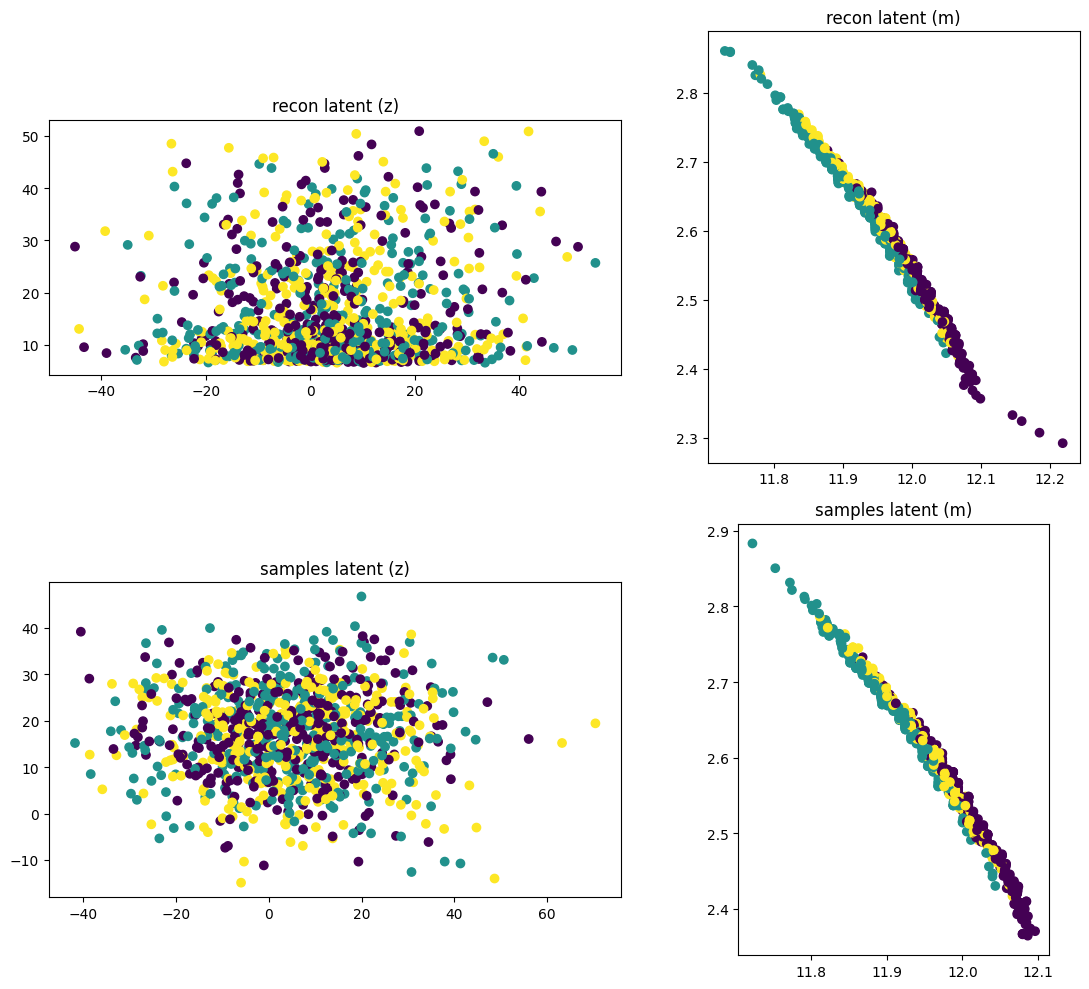

In [54]:
rng_key, sub_key = jax.random.split(rng_key)
plot_vae(learned_mean_stein_guide_flow_vae, sub_key, False)

In [6]:
import jax
import jax.numpy as jnp
import numpyro
import numpyro.distributions as dist
from numpyro import handlers

# A simple model that samples a mean (mu) and observes some data
def my_model(data):
    mu = numpyro.sample("mu", dist.Normal(0, 1))
    return numpyro.sample("obs", dist.Normal(mu, 1), obs=data)

dummy_data = jnp.array(1.5)

In [ ]:
# 1. We create the seeded model globally. 
# It now holds internal state in Python memory.


# 2. We tell JAX to compile this function using @jax.jit
@jax.jit
def run_bad_inference(data):
    return my_model(data)

bad_seeded_model = handlers.seed(run_bad_inference, rng_seed=0)
# 3. We try to run it...
try:
    print("Running the BAD way...")
    result = bad_seeded_model(dummy_data)
    bad_seeded_model = handlers.seed(run_bad_inference, rng_seed=0)
    result2 = bad_seeded_model(dummy_data*2)

except Exception as e:
    print(f"FAILED! Caught error:\n{type(e).__name__}: {e}\n")
result

Running the BAD way...


Array(1.5, dtype=float32, weak_type=True)

Array(1.5, dtype=float32, weak_type=True)